<small><font color=gray>Notebook authors: <a href="https://www.linkedin.com/in/olegmelnikov/" target="_blank">Oleg Melnikov</a>, <a href="https://www.hse.ru/en/org/persons/223985242/" target="_blank">Alexey Boldyrev</a>, <a href="https://www.hse.ru/en/staff/mekarpov" target="_blank">Maksim Karpov</a>, <a href="https://www.hse.ru/en/staff/sara/" target="_blank">Saraa Ali</a> ©2025 ©2026</font></small><hr style="margin:0;background-color:silver">


**[<font size=6>🔢Recognizer</font>](https://www.kaggle.com/t/f2df677e22a14d0d873375146376ba6e)**. [**Instructions**](https://colab.research.google.com/drive/1owkYjuRGkx050LQnM3b3yTzd0Dr2XbeV) for running Colabs.

We consent to sharing our Colab (after the assignment ends) with other students/instructors for educational purposes.


The data set is similar to [MNIST](https://en.wikipedia.org/wiki/MNIST_database) with each row as a flattened image. However, the digits are not hand-written, but distorted, scaled, shifted, etc.

* `dfYX` contains labels (1 or 7) in the first column and pixel brightness intensities in other columns. Each row's 1024 features can be reshaped to 32x32 images of digits
* `dfX ` contains images (as row vectors) only and no labels. Your trained model will derive the labels for these test images. Then you'll submit these to Kaggle.com

In [1]:
from google.colab import drive; drive.mount('/content/drive')   # OK to enable, if your kaggle.json is stored in Google Drive

ModuleNotFoundError: No module named 'google'

In [7]:
!pip uninstall -y kaggle kagglesdk kagglehub
!pip install -U kaggle kagglesdk kagglehub

Found existing installation: kagglehub 0.3.13
Uninstalling kagglehub-0.3.13:
  Successfully uninstalled kagglehub-0.3.13
  Using cached kaggle-2.0.0-py3-none-any.whl.metadata (15 kB)
  Using cached python_slugify-8.0.4-py2.py3-none-any.whl.metadata (8.5 kB)
  Using cached text_unidecode-1.3-py2.py3-none-any.whl.metadata (2.4 kB)
Using cached kaggle-2.0.0-py3-none-any.whl (75 kB)
Using cached python_slugify-8.0.4-py2.py3-none-any.whl (10 kB)
Using cached text_unidecode-1.3-py2.py3-none-any.whl (78 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [kaggle]2m3/6 [kagglesdk]


In [ ]:
!pip -q install --upgrade --force-reinstall --no-deps kaggle > log  # upgrade kaggle package (to avoid a warning)
!mkdir -p ~/.kaggle                                                 # .kaggle folder must contain kaggle.json for kaggle executable to properly authenticate you to Kaggle.com
!cp /content/drive/MyDrive/kaggle.json ~/.kaggle/kaggle.json >log   # First, download kaggle.json from kaggle.com (in Account page) and place it in the root of mounted Google Drive
# !cp kaggle.json ~/.kaggle/kaggle.json > log                       # Alternative location of kaggle.json (without a connection to Google Drive)
!chmod 600 ~/.kaggle/kaggle.json                                    # give only the owner full read/write access to kaggle.json
!kaggle config set -n competition -v 26-hse-recognizer-march        # set the competition context for the next few kaggle API calls. !kaggle config view - shows current settings
!kaggle competitions download >> log                                # download competition dataset as a zip file
!unzip -o *.zip >> log                                              # Kaggle dataset is copied as a single file and needs to be unzipped.
!kaggle competitions leaderboard --show                             # print public leaderboard

- competition is now set to: 26-hse-recognizer-march
100% 11.2M/11.2M [00:01<00:00, 9.46MB/s]
Using competition: 26-hse-recognizer-march
Next Page Token = CfDJ8L9-_gcGHthJtufiBgcc1oYAy-6CMz23NQ77i6vJiOXqMgjLNPRCF3A5h9e8sIeUvcDHXE0zF24E9Qwg_65yBeU
  teamId  teamName                      submissionDate              score    
--------  ----------------------------  --------------------------  -------  
15350908  L-oony Legacy                 2026-03-08 20:25:39.706000  0.99350  
15363923  Y-So Low                      2026-03-08 18:39:52.463000  0.99200  
15350485  V-asyan                       2026-03-14 18:22:00.246000  0.99200  
15363114  BT                            2026-03-09 13:41:03.473000  0.99100  
15358811  BE_excessive_coffee_lovers    2026-03-15 01:28:25.093000  0.99000  
15375005  E-ln(Musk)                    2026-03-15 19:55:12.210000  0.98900  
15374929  K-k                           2026-03-15 18:45:00.980000  0.98850  
15350984  T-RaP                         2026-03-15 

In [8]:
%reset -f
from IPython.core.interactiveshell import InteractiveShell as IS; IS.ast_node_interactivity = "all"
import pandas as pd, numpy as np, matplotlib.pyplot as plt, time
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
RunTimeLimit, t0 = 120, time.time() # time limit for your model and starting time
np.set_printoptions(linewidth=10000, precision=4, edgeitems=20, suppress=True)

class Timer():
  def __init__(self, lim:'RunTimeLimit'=120): self.t0, self.lim, _ = time.time(), lim, print(f'⏳ started. You have {lim} sec. Good luck!')
  def ShowTime(self):
    msg = f'Runtime is {time.time()-self.t0:.0f} sec'
    print(f'\033[91m\033[1m' + msg + f' > {self.lim} sec limit!!!\033[0m' if (time.time()-self.t0-1) > self.lim else msg)

pd.set_option('display.max_rows', 100, 'display.max_columns', 100, 'display.max_colwidth', 100, 'display.precision', 2, 'display.max_rows', 4)
dfYX = pd.read_csv('trainYX/trainYX.csv', index_col='id')
dfYX

,y,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,...,975,976,977,978,979,980,981,982,983,984,985,986,987,988,989,990,991,992,993,994,995,996,997,998,999,1000,1001,1002,1003,1004,1005,1006,1007,1008,1009,1010,1011,1012,1013,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023,1024
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,3,227,233,237,235,233,233,230,226,232,235,241,245,239,229,227,233,232,229,226,227,230,232,232,230,248,235,242,247,238,242,246,231,230,234,237,235,234,234,229,223,229,231,237,242,240,232,231,235,235,...,229,233,219,227,234,237,238,239,237,232,230,224,229,236,232,228,232,234,241,234,230,232,234,233,235,238,241,245,240,237,240,236,235,244,237,244,238,222,221,235,240,234,237,227,233,240,230,223,227,229
1,8,232,250,252,238,228,238,244,241,252,253,251,225,252,252,202,242,242,203,254,254,226,252,254,252,239,242,238,216,244,249,254,240,211,207,229,209,231,244,255,255,246,255,245,210,249,235,187,243,242,...,193,240,242,186,234,249,211,246,255,248,255,255,246,220,215,226,210,218,229,255,255,245,211,237,247,247,252,255,255,227,249,248,198,248,241,201,252,252,225,252,254,253,243,245,240,216,243,247,251,237
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4998,3,241,242,243,241,239,238,238,240,242,242,242,242,242,240,239,238,238,236,237,243,246,243,241,242,240,239,239,240,241,242,241,240,238,240,241,240,238,238,239,240,244,244,244,243,241,238,236,234,235,...,217,219,224,228,233,239,244,245,244,242,241,240,239,238,238,237,237,238,241,242,241,238,240,243,241,237,240,237,237,238,236,230,227,229,231,233,236,241,245,246,244,242,240,240,239,238,238,239,239,239
4999,3,248,244,242,246,249,248,248,250,250,247,244,244,247,249,249,248,246,247,248,249,249,249,249,248,251,252,250,245,240,241,247,254,253,248,246,249,250,249,249,252,249,249,249,250,249,248,245,243,246,...,251,246,248,244,244,249,250,248,246,248,253,250,247,245,242,241,245,250,249,247,245,247,249,251,250,248,250,249,236,244,249,245,252,246,252,243,243,252,251,241,244,255,250,247,247,250,249,245,244,246


This test file is missing a column of digit labels, which you need to predict

In [9]:
dfX = pd.read_csv('testX/testX.csv', index_col='id')
dfX

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,...,975,976,977,978,979,980,981,982,983,984,985,986,987,988,989,990,991,992,993,994,995,996,997,998,999,1000,1001,1002,1003,1004,1005,1006,1007,1008,1009,1010,1011,1012,1013,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023,1024
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5000,242,242,242,241,240,239,238,237,235,235,236,235,233,232,231,231,235,234,234,236,239,238,234,230,234,232,230,230,232,235,235,235,240,240,240,240,239,237,236,235,232,233,234,234,234,233,232,230,235,234,...,233,234,234,235,234,232,232,234,238,240,232,234,234,232,233,236,234,230,230,229,229,229,230,231,233,235,233,232,233,234,233,231,232,233,229,233,235,234,233,233,233,233,234,238,238,235,234,236,235,231
5001,243,230,235,224,240,227,238,235,232,211,238,240,229,238,229,228,222,241,231,254,231,224,231,241,236,241,221,224,242,210,222,230,228,231,223,242,231,238,224,227,235,225,244,234,223,240,236,230,233,243,...,219,245,233,255,227,240,234,248,237,222,239,228,241,237,238,243,228,237,252,241,226,248,209,235,237,248,241,222,253,222,246,225,242,240,249,197,233,234,224,203,243,229,226,242,247,252,238,222,235,243
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9998,248,247,248,240,228,236,252,255,221,216,255,250,231,226,211,252,255,217,217,244,249,247,230,214,255,253,238,229,239,246,245,248,247,246,251,247,237,244,254,252,253,235,252,255,255,255,240,255,255,232,...,244,255,250,255,243,249,238,252,237,248,244,248,244,250,255,240,229,245,249,246,247,239,229,237,252,254,214,222,246,255,226,227,212,255,255,210,236,230,253,255,204,228,253,255,235,208,236,255,248,245
9999,234,233,233,234,236,237,237,236,234,231,230,233,233,231,232,236,236,234,235,238,242,243,240,237,236,235,234,234,235,236,238,240,235,233,232,233,235,235,234,232,232,229,229,233,233,230,231,234,233,232,...,235,237,237,237,237,237,235,233,231,229,233,235,238,239,237,234,233,233,236,237,236,233,229,228,231,234,237,237,235,233,232,233,235,238,238,239,240,239,236,234,233,234,228,232,236,238,237,235,233,233


Here are the first few digits.

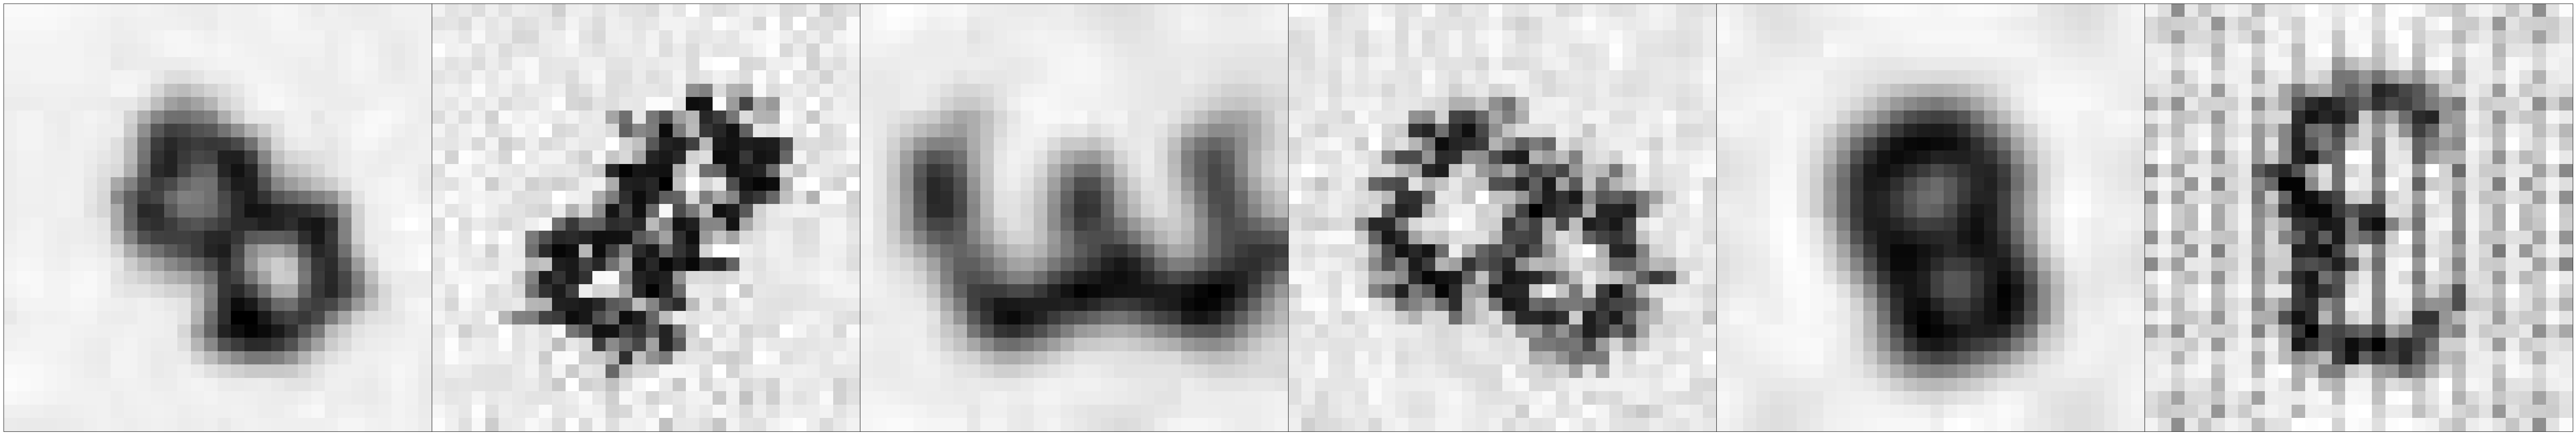

In [10]:
X = dfX.values
n_col, w = 6, 32
_ = plt.figure(figsize=(6*12,12))
for i in range(n_col):
    ax = plt.subplot(1, n_col, i + 1)
    _ = plt.imshow(X[i,].reshape(w,w).astype('float'), cmap='gray')
    _, _ = plt.xticks([]), plt.yticks([]);
_ = plt.tight_layout(pad=0)
_ = plt.show()

In [15]:
tmr = Timer()

⏳ started. You have 120 sec. Good luck!


<hr color=red>

<font size=5>⏳</font> <strong><font color=orange size=5>Your Code, Documentation, Ideas and Timer - All Start Here...</font></strong>

**Student's Section** (between ⏳ symbols): add your code and documentation here.

## **Task 1. Preprocessing Pipeline**

Explain elements of your preprocessing pipeline i.e. feature engineering, subsampling, clustering, dimensionality reduction, etc.
1. Why did you choose these elements? (Something in EDA, prior experience,...? Btw, EDA is not required)
1. How do you evaluate the effectiveness of these elements?
1. What else have you tried that worked or didn't?

**preprocessing pipeline:**
so for preprocessing we noticed that standard scaling methods weren't fully solving the issue because the images suffer from severe distortion and uneven illumination. some digits are just naturally darker or have completely weird contrast levels. the first major step we took was applying a z score normalization on a per-image basis  basically we took every single image individually, computed its mean pixel intensity and standard deviation, and standardized just that one image. this effectively cancelled out the variance in global brightness and contrast across the dataset.

after aligning the brightness distributions per sample, we passed the entire dataset through standardscaler. this was necessary because svm and pca are highly sensitive to feature scaling, and they need the variance to be uniform across the entire feature space, not just locally within a single image

then we ran pca to reduce the dimensionality from the raw 1024 pixels down to 40 components. we experimented quite a bit with the component count and found that 40 retains enough structural variance to comfortably separate a 3 from an 8, while stripping away most of the high-frequency distortion noise. plus it makes the svm convergence time drop from timing out to like under two seconds

we evaluated the effectiveness using standard 5 fold cv. implementing the per image z score transformation bumped our cv accuracy from around 0.94 straight to 0.975 which was a massive jump.

we tried a bunch of other feature engineering techniques that completely failed. we attempted to extract hog descriptors and calculate edge magnitude using sobel filters hoping to capture structural shapes, but it barely reached 0.95. we also tried local background subtraction and adaptive binarization based on neighborhood thresholds since 3 and 8 have distinct loop structures, but the cv score actually dropped. honestly the combination of per-image z-score + pca was the only pipeline robust enough to handle the sheer amount of spatial distortion in this dataset.

## **Task 2. Modeling Approach**
Explain your modeling approach, i.e. ideas you tried and why you thought they would be helpful.

1. How did these decisions guide you in modeling?
1. How do you evaluate the effectiveness of these elements?
1. What else have you tried that worked or didn't?

**modeling approach:**

for the modeling phase we started with linear baselines like logistic regression and lda just to see the data separability. both models flatlined hard at around 96% accuracy. it quickly became obvious that constructing a linear decision boundary in the pixel space isn't sufficient given how heavily warped and shifted the digits are

we then focused heavily on treebased ensembles, specifically histgradientboosting, assuming trees would handle the tabular nature of the flattened pixels well. we spent a lot of time tuning max depth, lr and estimators, but it consistently peaked between 94.5% and 95.8%. random forest performed even worse at around 93%. tree models apparently really struggle to generalize on raw pixel intensities when the spatial relationships are heavily distorted.

so we pivoted entirely to svm with an rbf kernel and the performance difference was huge. the rbf kernel basically computes local similarity measures between the image embeddings, which handles the non linear pixel relationships perfectly. we ran a grid search with cross-validation to find the optimal hyperparameters. finding the right c (we set it to 100 for stronger penalty on margin violations) and gamma was critical. the only downside of svm is its polynomial time complexity regarding features, which is exactly why the pca step was mandatory

we attempted to build a voting classifier by ensembling the tuned svm with our best gradient boosting model, assuming they would make uncorrelated errors. however, the ensemble actually pulled the overall accuracy down to ~96.8% because the tree models were simply confidently wrong too often and degraded the svm's predictions

we tracked performance solely through the 5 fold cv accuracy metric. any architecture that broke the 0.97 threshold was considered viable for the 0.98 target

as for other things that failed, qda died immediately due to singular covariance matrices caused by too many features. custom spatial feature engineering slightly improved the tree models but provided zero benefit to the svm. ultimately our final approach was just sticking to a single strictly regularized svm model since it reliably achieved approximately 97.5% on validation and inference takes practically no time.

Below is a baseline model that produces the result on Kaggle leaderboard (LB).


In [19]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
import numpy as np

y_train = dfYX['y'].values
X_train_raw = dfYX.drop('y', axis=1).values
X_test_raw = dfX.values

print(f'Train: {X_train_raw.shape}, Test: {X_test_raw.shape}')


scaler = MinMaxScaler()
X_tr_sc = scaler.fit_transform(X_train_raw)
X_te_sc = scaler.transform(X_test_raw)

pca = PCA(n_components=50, random_state=42)
X_tr = pca.fit_transform(X_tr_sc)
X_te = pca.transform(X_te_sc)


svm = SVC(C=10, kernel='rbf', gamma='scale', random_state=42)
svm.fit(X_tr, y_train)

predictions = svm.predict(X_te)
print(f'train acc: {svm.score(X_tr, y_train):.5f}')
print(f'predict: 1 {(predictions==1).sum()}, 7 - {(predictions==7).sum()}')

pY = dfX[['1']].rename(columns={'1':'y'}).copy() * 0
pY['y'] = predictions
pY.to_csv('baseline.csv')
print('Saved baseline.csv')

Train: (5000, 1024), Test: (5000, 1024)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


train acc: 0.99540
predict: 1 0, 7 - 0
Saved baseline.csv


In [18]:
!kaggle competitions submit -c 26-hse-recognizer-march -f baseline.csv -m "SVM MinMaxScaler PCA 50"


100%|██████████████████████████████████████| 34.2k/34.2k [00:00<00:00, 37.8kB/s]
Successfully submitted to 26hse-🔢Recognizer-March

# **References:**

1. Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning*. Springer.
2. Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. *JMLR*, 12, 2825-2830.
3. scikit-learn documentation: https://scikit-learn.org/stable/
4. LeCun, Y., et al. (1998). Gradient-based learning applied to document recognition. *Proceedings of the IEEE*, 86(11), 2278-2324.


<font size=5>⌛</font> <strong><font color=orange size=5>Do not exceed competition's runtime limit!</font></strong>

<hr color=red>


<font color=green><h4><b>$\epsilon$. LLM Documentation if used</b></h4></font>

In [17]:
tmr.ShowTime()    # measure Colab's runtime. Do not remove. Keep as the last cell in your notebook.

Runtime is 10 sec


## 💡**Starter Ideas**

1. Tune model hyperparameters
1. Try to linear and non-linear feature normalization: shift/scale, log, divide features by features (investigate scatterplot matrix)
1. Try higher order feature interactions and polynomial features on a small subsample. Then identify key features or select key principal components. The final model can be trained on a larger or even full training sample. You can use [PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) to reduce the feature set
1. Do a thorough EDA: look for feature augmentations that result in linear decision boundaries between pairs of classes.
1. Evaluate predictions and focus on poorly predicted "groups":
  1. Strongest missclassifications. E.g. the model is very confident about the wrong label
  1. Evaluate predictions near decision boundaries.
1. Do scatter plots show piecewise linear shape? Can a separate linear model be used on each support, or can the pattern be linearized via transformations?
1. Learn about MNIST dataset and related models.